In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

np.random.seed(42)
tf.random.set_seed(42)

RESULTS_DIR = Path("results_rnn_lstm")
RESULTS_DIR.mkdir(exist_ok=True)

print("Setup complete.")

TensorFlow: 2.21.0
GPU: []
Setup complete.


In [2]:
train = pd.read_csv("train_scaled.csv")
val = pd.read_csv("validation_scaled.csv")
test = pd.read_csv("test_scaled.csv")

TARGET = "label"

X_train = train.drop(columns=[TARGET]).values.astype("float32")
y_train = train[TARGET].values.astype("int32")

X_val = val.drop(columns=[TARGET]).values.astype("float32")
y_val = val[TARGET].values.astype("int32")

X_test = test.drop(columns=[TARGET]).values.astype("float32")
y_test = test[TARGET].values.astype("int32")

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("Train labels:", np.bincount(y_train))
print("Test labels:", np.bincount(y_test))

Train: (164490, 50)
Validation: (35248, 50)
Test: (35249, 50)
Train labels: [70096 94394]
Test labels: [15021 20228]


In [3]:
X_train_seq = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_seq = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test_seq = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("Train sequence shape:", X_train_seq.shape)
print("Validation sequence shape:", X_val_seq.shape)
print("Test sequence shape:", X_test_seq.shape)

Train sequence shape: (164490, 50, 1)
Validation sequence shape: (35248, 50, 1)
Test sequence shape: (35249, 50, 1)


In [4]:
rnn = Sequential([
    tf.keras.Input(shape=(X_train_seq.shape[1], 1)),
    SimpleRNN(32),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

rnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

rnn.summary()

early_stop_rnn = EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True
)

history_rnn = rnn.fit(
    X_train_seq,
    y_train,
    validation_data=(X_val_seq, y_val),
    epochs=6,
    batch_size=1024,
    callbacks=[early_stop_rnn],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,633 (6.38 KB)

 Trainable params: 1,633 (6.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/6
161/161 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.9492 - loss: 0.1576 - val_accuracy: 0.9847 - val_loss: 0.0501
Epoch 2/6
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9909 - loss: 0.0297 - val_accuracy: 0.9957 - val_loss: 0.0151
Epoch 3/6
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9970 - loss: 0.0112 - val_accuracy: 0.9977 - val_loss: 0.0081
Epoch 4/6
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9984 - loss: 0.0061 - val_accuracy: 0.9991 - val_loss: 0.0034
Epoch 5/6
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9988 - loss: 0.0048 - val_accuracy: 0.9986 - val_loss: 0.0042


In [5]:
rnn_prob = rnn.predict(X_test_seq, batch_size=1024).ravel()
rnn_pred = (rnn_prob >= 0.5).astype(int)

print("RNN Classification Report")
print(classification_report(
    y_test,
    rnn_pred,
    target_names=["Phishing", "Legitimate"],
    digits=4
))

print("RNN Confusion Matrix")
print(confusion_matrix(y_test, rnn_pred))

print("RNN ROC-AUC:", roc_auc_score(y_test, rnn_prob))

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
RNN Classification Report
              precision    recall  f1-score   support

    Phishing     0.9997    0.9987    0.9992     15021
  Legitimate     0.9990    0.9998    0.9994     20228

    accuracy                         0.9993     35249
   macro avg     0.9994    0.9992    0.9993     35249
weighted avg     0.9993    0.9993    0.9993     35249

RNN Confusion Matrix
[[15001    20]
 [    4 20224]]
RNN ROC-AUC: 0.9999941351635098


In [6]:
lstm = Sequential([
    tf.keras.Input(shape=(X_train_seq.shape[1], 1)),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

lstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm.summary()

early_stop_lstm = EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True
)

history_lstm = lstm.fit(
    X_train_seq,
    y_train,
    validation_data=(X_val_seq, y_val),
    epochs=6,
    batch_size=1024,
    callbacks=[early_stop_lstm],
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/6
161/161 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - accuracy: 0.9212 - loss: 0.2598 - val_accuracy: 0.9499 - val_loss: 0.1191
Epoch 2/6
161/161 ━━━━━━━━━━━━━━━━━━━━ 16s 101ms/step - accuracy: 0.9758 - loss: 0.0651 - val_accuracy: 0.9833 - val_loss: 0.0464
Epoch 3/6
161/161 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - accuracy: 0.9851 - loss: 0.0421 - val_accuracy: 0.9877 - val_loss: 0.0348
Epoch 4/6
161/161 ━━━━━━━━━━━━━━━━━━━━ 16s 99ms/step - accuracy: 0.9875 - loss: 0.0356 - val_accuracy: 0.9892 - val_loss: 0.0307
Epoch 5/6
161/161 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - accuracy: 0.9894 - loss: 0.0306 - val_accuracy: 0.9904 - val_loss: 0.0280
Epoch 6/6
161/161 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - accuracy: 0.9909 - loss: 0.0268 - val_accuracy: 0.9922 - val_loss: 0.0220


In [7]:
lstm_prob = lstm.predict(X_test_seq, batch_size=1024).ravel()
lstm_pred = (lstm_prob >= 0.5).astype(int)

print("LSTM Classification Report")
print(classification_report(
    y_test,
    lstm_pred,
    target_names=["Phishing", "Legitimate"],
    digits=4
))

print("LSTM Confusion Matrix")
print(confusion_matrix(y_test, lstm_pred))

print("LSTM ROC-AUC:", roc_auc_score(y_test, lstm_prob))

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step
LSTM Classification Report
              precision    recall  f1-score   support

    Phishing     0.9925    0.9896    0.9911     15021
  Legitimate     0.9923    0.9945    0.9934     20228

    accuracy                         0.9924     35249
   macro avg     0.9924    0.9920    0.9922     35249
weighted avg     0.9924    0.9924    0.9924     35249

LSTM Confusion Matrix
[[14865   156]
 [  112 20116]]
LSTM ROC-AUC: 0.9996717435877164


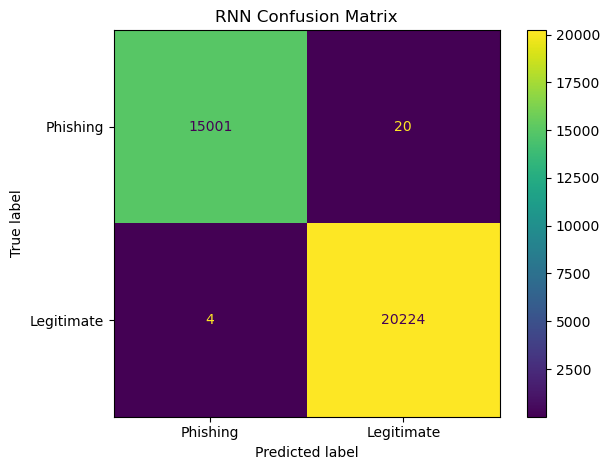

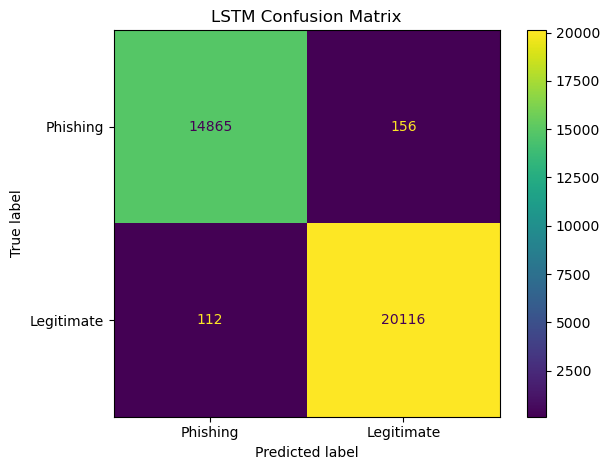

  Model  Accuracy  Phishing Precision  Phishing Recall  Phishing F1   ROC-AUC  \
0   RNN  0.999319            0.999733         0.998669     0.999201  0.999994   
1  LSTM  0.992397            0.992522         0.989615     0.991066  0.999672   

   Phishing Missed  Legitimate Flagged  
0               20                   4  
1              156                 112  

Saved to: results_rnn_lstm


In [8]:
def calculate_results(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Phishing Precision": precision_score(y_true, y_pred, pos_label=0),
        "Phishing Recall": recall_score(y_true, y_pred, pos_label=0),
        "Phishing F1": f1_score(y_true, y_pred, pos_label=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "Phishing Missed": int(((y_true == 0) & (y_pred == 1)).sum()),
        "Legitimate Flagged": int(((y_true == 1) & (y_pred == 0)).sum())
    }

results = pd.DataFrame([
    calculate_results("RNN", y_test, rnn_pred, rnn_prob),
    calculate_results("LSTM", y_test, lstm_pred, lstm_prob)
])

results.to_csv(
    RESULTS_DIR / "rnn_lstm_results.csv",
    index=False
)

for name, pred in [("RNN", rnn_pred), ("LSTM", lstm_pred)]:
    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Phishing", "Legitimate"]
    )

    disp.plot(values_format="d")
    plt.title(f"{name} Confusion Matrix")
    plt.tight_layout()
    plt.savefig(
        RESULTS_DIR / f"{name}_cm.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

print(results.round(6))
print("\nSaved to:", RESULTS_DIR)